# Adım 1: Sistem Kütüphanelerinin Kurulması
OpenCV'yi C++ üzerinde kullanabilmek için gerekli paketleri kuruyoruz.

In [12]:
!apt-get update
!apt-get install -y libopencv-dev build-essential cmake

Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:4 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Hit:7 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information...

# Adım 2: C++ Kaynak Kodunun Oluşturulması (`main.cpp`)
Resimleri tek kanallı gri tonlamalı olarak yükleyen, doğrusal kontrast germe işlemini uygulayan ve sonuçları kaydeden C++ kodunu yazıyoruz.

In [13]:
%%writefile main.cpp
#include <opencv2/opencv.hpp>
#include <iostream>
#include <vector>

int main() {
    // İşlenecek resim listesi
    std::vector<std::string> dosya_isimleri = {"resim1.jpeg", "resim2.jpeg"};

    for (const std::string& dosya_adi : dosya_isimleri) {
        // Resmi gri tonlamalı oku
        cv::Mat image = cv::imread(dosya_adi, cv::IMREAD_GRAYSCALE);

        if (image.empty()) {
            std::cerr << "Hata: " << dosya_adi << " bulunamadı veya okunamadı!" << std::endl;
            continue;
        }

        // Minimum ve maksimum piksel değerlerini bul
        double min_val, max_val;
        cv::minMaxLoc(image, &min_val, &max_val);

        std::cout << "----------------------------------------" << std::endl;
        std::cout << "İşlenen Dosya: " << dosya_adi << std::endl;
        std::cout << "Bulunan Min Değer: " << min_val << " | Max Değer: " << max_val << std::endl;

        // Doğrusal Kontrast Germe (0-255 aralığına normalize etme)
        cv::Mat stretched_image;
        cv::normalize(image, stretched_image, 0, 255, cv::NORM_MINMAX, CV_8U);

        // Çıktıyı diske kaydet
        std::string cikti_adi = "cikti_" + dosya_adi;
        cv::imwrite(cikti_adi, stretched_image);
        std::cout << "Başarıyla kaydedildi: " << cikti_adi << std::endl;
    }

    std::cout << "----------------------------------------" << std::endl;
    std::cout << "Tüm işlemler tamamlandı!" << std::endl;

    return 0;
}

Overwriting main.cpp


# Adım 3: Derleme ve Çalıştırma
C++ kodunu OpenCV bayrakları ile derliyor ve çalıştırıyoruz.

In [14]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4`
!./app

----------------------------------------
İşlenen Dosya: resim1.jpeg
Bulunan Min Değer: 92 | Max Değer: 249
Başarıyla kaydedildi: cikti_resim1.jpeg
----------------------------------------
İşlenen Dosya: resim2.jpeg
Bulunan Min Değer: 92 | Max Değer: 249
Başarıyla kaydedildi: cikti_resim2.jpeg
----------------------------------------
Tüm işlemler tamamlandı!


# Adım 4: Sonuçların Görselleştirilmesi
Orijinal resimler ile kontrastı gerilmiş çıktı resimlerini yan yana ekrana çizdiriyoruz.

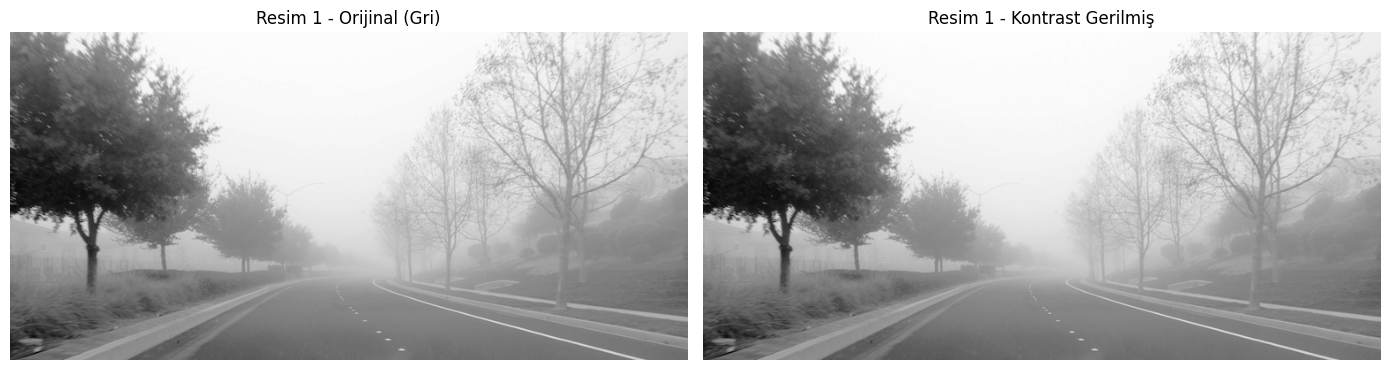

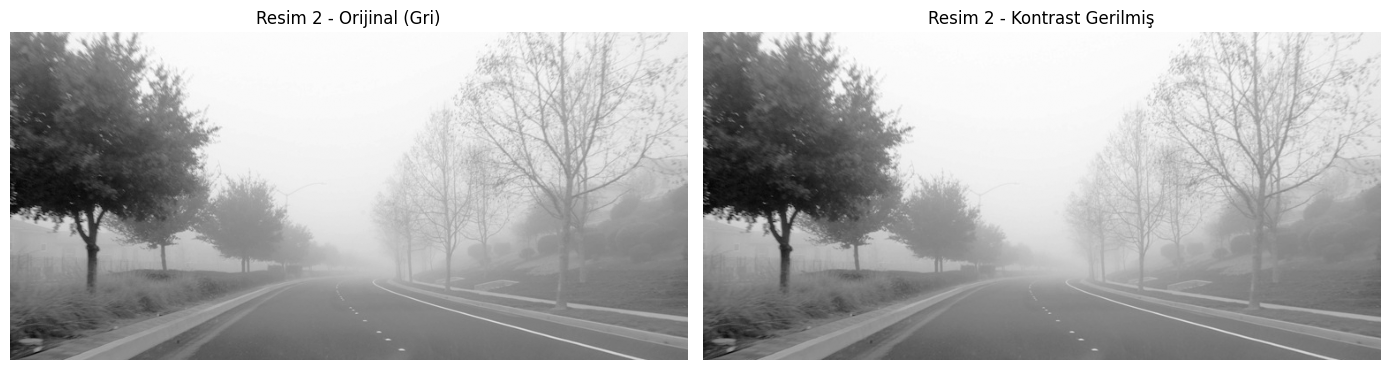

In [15]:
import cv2
import matplotlib.pyplot as plt

def resimleri_goster(orjinal_yol, cikti_yol, baslik):
    # Resimleri oku
    original = cv2.imread(orjinal_yol, cv2.IMREAD_GRAYSCALE)
    processed = cv2.imread(cikti_yol, cv2.IMREAD_GRAYSCALE)

    if original is None or processed is None:
        print(f"Hata: Resimler yüklenemedi! Yollar: {orjinal_yol}, {cikti_yol}")
        return

    # Grafik oluştur
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title(f"{baslik} - Orijinal (Gri)")
    axes[0].axis('off')

    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title(f"{baslik} - Kontrast Gerilmiş")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Resimleri karşılaştırmalı olarak ekrana bas
resimleri_goster('resim1.jpeg', 'cikti_resim1.jpeg', 'Resim 1')
resimleri_goster('resim2.jpeg', 'cikti_resim2.jpeg', 'Resim 2')

In [1]:
!apt-get update
!apt-get install -y libopencv-dev build-essential cmake

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:4 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Get:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:7 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,884 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:9 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:11 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1,543 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [2,127 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/p

In [2]:
%%writefile main.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <cuda_runtime.h>

int main() {
    std::cout << "--- Sistem Bilgileri ---" << std::endl;
    std::cout << "OpenCV Versiyonu: " << CV_VERSION << std::endl;

    int deviceCount = 0;
    cudaError_t error = cudaGetDeviceCount(&deviceCount);

    if (error == cudaSuccess && deviceCount > 0) {
        std::cout << "CUDA Durumu: Başarılı! Colab GPU Algılandı." << std::endl;
        std::cout << "Algılanan GPU Sayısı: " << deviceCount << std::endl;
    } else {
        std::cout << "CUDA Durumu: Cihaz bulunamadı veya GPU aktif değil!" << std::endl;
    }

    return 0;
}

Writing main.cpp


In [3]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4` -I/usr/local/cuda/include -L/usr/local/cuda/lib64 -lcudart
!./app

--- Sistem Bilgileri ---
OpenCV Versiyonu: 4.6.0
CUDA Durumu: Başarılı! Colab GPU Algılandı.
Algılanan GPU Sayısı: 1


In [ ]:
görev 1


In [22]:
%%writefile main.cpp
#include <opencv2/opencv.hpp>
#include <iostream>
#include <vector>

int main() {
    // 1. İşlenecek resim dosyalarının listesi
    std::vector<std::string> dosya_isimleri = {"resim1.jpeg", "resim2.jpeg"};

    for (const std::string& dosya_adi : dosya_isimleri) {
        // Resmi gri tonlamalı (tek kanallı) olarak oku
        cv::Mat image = cv::imread(dosya_adi, cv::IMREAD_GRAYSCALE);

        if (image.empty()) {
            std::cerr << "Hata: " << dosya_adi << " bulunamadı veya okunamadı!" << std::endl;
            continue;
        }

        // 2. Minimum ve maksimum piksel değerlerini bul
        double min_val, max_val;
        cv::minMaxLoc(image, &min_val, &max_val);

        std::cout << "----------------------------------------" << std::endl;
        std::cout << "İşlenen Dosya: " << dosya_adi << std::endl;
        std::cout << "Bulunan Min Değer: " << min_val << " | Max Değer: " << max_val << std::endl;

        // 3. Doğrusal Kontrast Germe (Linear Contrast Stretching)
        cv::Mat stretched_image;
        cv::normalize(image, stretched_image, 0, 255, cv::NORM_MINMAX, CV_8U);

        // 4. İşlenen sonucu kaydet (Sol panelde görebilmen için)
        std::string cikti_adi = "cikti_" + dosya_adi;
        cv::imwrite(cikti_adi, stretched_image);
        std::cout << "Başarıyla kaydedildi: " << cikti_adi << std::endl;
    }

    std::cout << "----------------------------------------" << std::endl;
    std::cout << "Tüm işlemler tamamlandı!" << std::endl;

    return 0;
}

Overwriting main.cpp


In [18]:
%%writefile main.cpp
#include <opencv2/opencv.hpp>
#include <iostream>
#include <vector>

int main() {
    // 1. İşlenecek resim dosyalarının listesi
    std::vector<std::string> dosya_isimleri = {"resim1.jpeg", "resim2.jpeg"};

    for (const std::string& dosya_adi : dosya_isimleri) {
        // Resmi gri tonlamalı (tek kanallı) olarak oku
        cv::Mat image = cv::imread(dosya_adi, cv::IMREAD_GRAYSCALE);

        if (image.empty()) {
            std::cerr << "Hata: " << dosya_adi << " bulunamadı veya okunamadı!" << std::endl;
            continue;
        }

        // 2. Minimum ve maksimum piksel değerlerini bul
        double min_val, max_val;
        cv::minMaxLoc(image, &min_val, &max_val);

        std::cout << "----------------------------------------" << std::endl;
        std::cout << "İşlenen Dosya: " << dosya_adi << std::endl;
        std::cout << "Bulunan Min Değer: " << min_val << " | Max Değer: " << max_val << std::endl;

        // 3. Doğrusal Kontrast Germe (Linear Contrast Stretching)
        cv::Mat stretched_image;
        cv::normalize(image, stretched_image, 0, 255, cv::NORM_MINMAX, CV_8U);

        // 4. İşlenen sonucu kaydet (Sol panelde görebilmen için)
        std::string cikti_adi = "cikti_" + dosya_adi;
        cv::imwrite(cikti_adi, stretched_image);
        std::cout << "Başarıyla kaydedildi: " << cikti_adi << std::endl;
    }

    std::cout << "----------------------------------------" << std::endl;
    std::cout << "Tüm işlemler tamamlandı!" << std::endl;

    return 0;
}

Overwriting main.cpp


In [19]:
!g++ main.cpp -o app `pkg-config --cflags --libs opencv4`
!./app

----------------------------------------
İşlenen Dosya: resim1.jpeg
Bulunan Min Değer: 0 | Max Değer: 237
Başarıyla kaydedildi: cikti_resim1.jpeg
----------------------------------------
İşlenen Dosya: resim2.jpeg
Bulunan Min Değer: 92 | Max Değer: 249
Başarıyla kaydedildi: cikti_resim2.jpeg
----------------------------------------
Tüm işlemler tamamlandı!


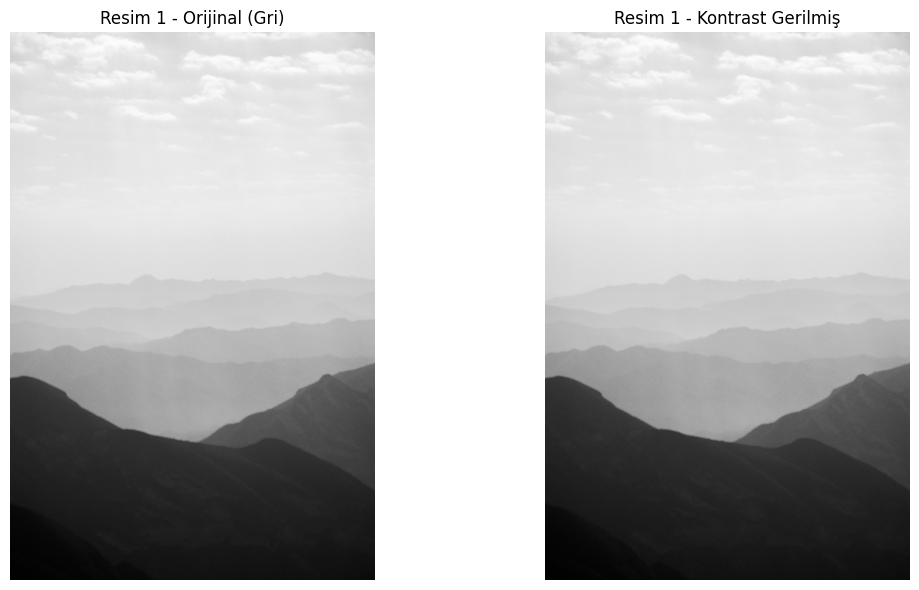

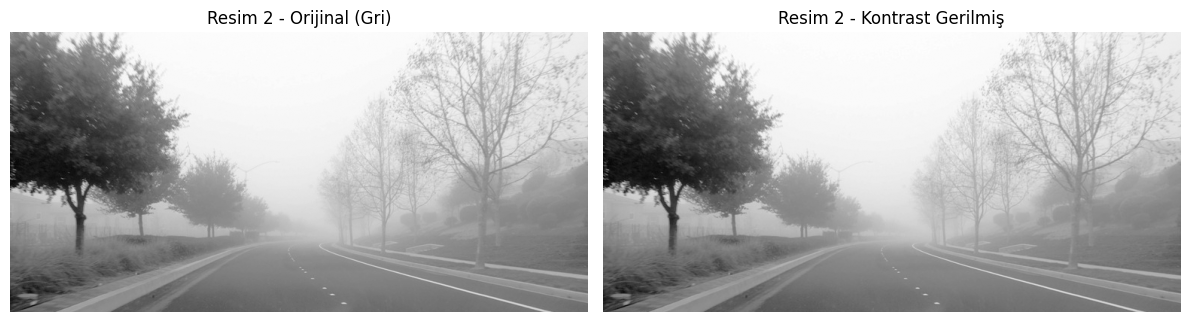

In [20]:
import cv2
import matplotlib.pyplot as plt

def resimleri_goster(orjinal_yol, cikti_yol, baslik):
    # Resimleri oku
    original = cv2.imread(orjinal_yol, cv2.IMREAD_GRAYSCALE)
    processed = cv2.imread(cikti_yol, cv2.IMREAD_GRAYSCALE)

    if original is None or processed is None:
        print(f"Hata: Resimler yüklenemedi! Yollar: {orjinal_yol}, {cikti_yol}")
        return

    # Yan yana çiz
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title(f"{baslik} - Orijinal (Gri)")
    axes[0].axis('off')

    axes[1].imshow(processed, cmap='gray')
    axes[1].set_title(f"{baslik} - Kontrast Gerilmiş")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Resim 1 için karşılaştırma
resimleri_goster('resim1.jpeg', 'cikti_resim1.jpeg', 'Resim 1')

# Resim 2 için karşılaştırma
resimleri_goster('resim2.jpeg', 'cikti_resim2.jpeg', 'Resim 2')